In [1]:
import os, re, glob, string, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import fitz  # PyMuPDF

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

from gensim.models import Word2Vec

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, classification_report,
                              adjusted_rand_score, normalized_mutual_info_score)
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

PDF_ROOT = "data/pdfs"      # category-wise folders of PDFs
CSV_PATH = "data/corpus.csv"

STOPWORDS = set(stopwords.words("english"))
print("Setup complete.")


Setup complete.


In [2]:
def extract_text_from_pdf(path):
    """Extract raw text from a single PDF using PyMuPDF."""
    text = ""
    with fitz.open(path) as doc:
        for page in doc:
            text += page.get_text()
    return text.strip()

records = []
categories = sorted([d for d in os.listdir(PDF_ROOT) if os.path.isdir(os.path.join(PDF_ROOT, d))])
print("Categories found:", categories)

for category in categories:
    pdf_files = sorted(glob.glob(os.path.join(PDF_ROOT, category, "*.pdf")))
    for pdf_path in pdf_files:
        raw_text = extract_text_from_pdf(pdf_path)
        records.append({
            "file_name": os.path.basename(pdf_path),
            "category": category,
            "raw_text": raw_text
        })

df = pd.DataFrame(records)
print(f"Total PDF documents read: {len(df)}")
df.head()


Categories found: ['Education', 'Finance', 'Health', 'Sports', 'Technology']
Total PDF documents read: 50


,file_name,category,raw_text
0,education_01_higher_education.pdf,Education,Higher education\nTertiary education (also cal...
1,education_02_distance_education.pdf,Education,"Distance education\nDistance education, also k..."
2,education_03_curriculum.pdf,Education,"Curriculum\nIn education, a curriculum (; pl.:..."
3,education_04_literacy.pdf,Education,Literacy\nLiteracy is the ability to read and ...
4,education_05_educational_technology.pdf,Education,Educational technology\nEducational technology...


In [3]:
URL_RE      = re.compile(r"https?://\S+|www\.\S+")
EMAIL_RE    = re.compile(r"\S+@\S+\.\S+")
NUMBER_RE   = re.compile(r"\d+")
PUNCT_RE    = re.compile(f"[{re.escape(string.punctuation)}]")
MULTISPACE_RE = re.compile(r"\s+")
TOKEN_RE    = re.compile(r"[a-z]+")  # tokenizer via regex


def clean_text(text):
    text = text.lower()                          # 1. lowercase
    text = URL_RE.sub(" ", text)                  # 2. remove URLs
    text = EMAIL_RE.sub(" ", text)                # 3. remove emails
    text = NUMBER_RE.sub(" ", text)                # 4. remove numbers
    text = PUNCT_RE.sub(" ", text)                # 5. remove punctuation
    text = MULTISPACE_RE.sub(" ", text).strip()   # 6. normalize spaces

    tokens = TOKEN_RE.findall(text)               # 7. regex tokenization
    tokens = [t for t in tokens if t not in STOPWORDS]   # 8. stop-word removal
    tokens = [t for t in tokens if len(t) >= 3]          # 9. remove very short tokens

    return tokens


df["tokens"] = df["raw_text"].apply(clean_text)
df["cleaned_text"] = df["tokens"].apply(lambda toks: " ".join(toks))

# Save the structured CSV required by the assignment
df_out = df[["file_name", "category", "raw_text", "cleaned_text"]]
os.makedirs("data", exist_ok=True)
df_out.to_csv(CSV_PATH, index=False)
print(f"Saved structured dataset -> {CSV_PATH}")
df_out.head()


Saved structured dataset -> data/corpus.csv


,file_name,category,raw_text,cleaned_text
0,education_01_higher_education.pdf,Education,Higher education\nTertiary education (also cal...,higher education tertiary education also calle...
1,education_02_distance_education.pdf,Education,"Distance education\nDistance education, also k...",distance education distance education also kno...
2,education_03_curriculum.pdf,Education,"Curriculum\nIn education, a curriculum (; pl.:...",curriculum education curriculum curriculums cu...
3,education_04_literacy.pdf,Education,Literacy\nLiteracy is the ability to read and ...,literacy literacy ability read write illiterac...
4,education_05_educational_technology.pdf,Education,Educational technology\nEducational technology...,educational technology educational technology ...


In [4]:
def make_ngrams(tokens, n):
    if len(tokens) < n:
        return []
    return ["_".join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

df["unigrams"] = df["tokens"]
df["bigrams"]  = df["tokens"].apply(lambda t: make_ngrams(t, 2))
df["trigrams"] = df["tokens"].apply(lambda t: make_ngrams(t, 3))

print("Example unigrams:", df['unigrams'].iloc[0][:8])
print("Example bigrams :", df['bigrams'].iloc[0][:8])
print("Example trigrams:", df['trigrams'].iloc[0][:8])


Example unigrams: ['higher', 'education', 'tertiary', 'education', 'also', 'called', 'higher', 'education']
Example bigrams : ['higher_education', 'education_tertiary', 'tertiary_education', 'education_also', 'also_called', 'called_higher', 'higher_education', 'education_post']
Example trigrams: ['higher_education_tertiary', 'education_tertiary_education', 'tertiary_education_also', 'education_also_called', 'also_called_higher', 'called_higher_education', 'higher_education_post', 'education_post_secondary']


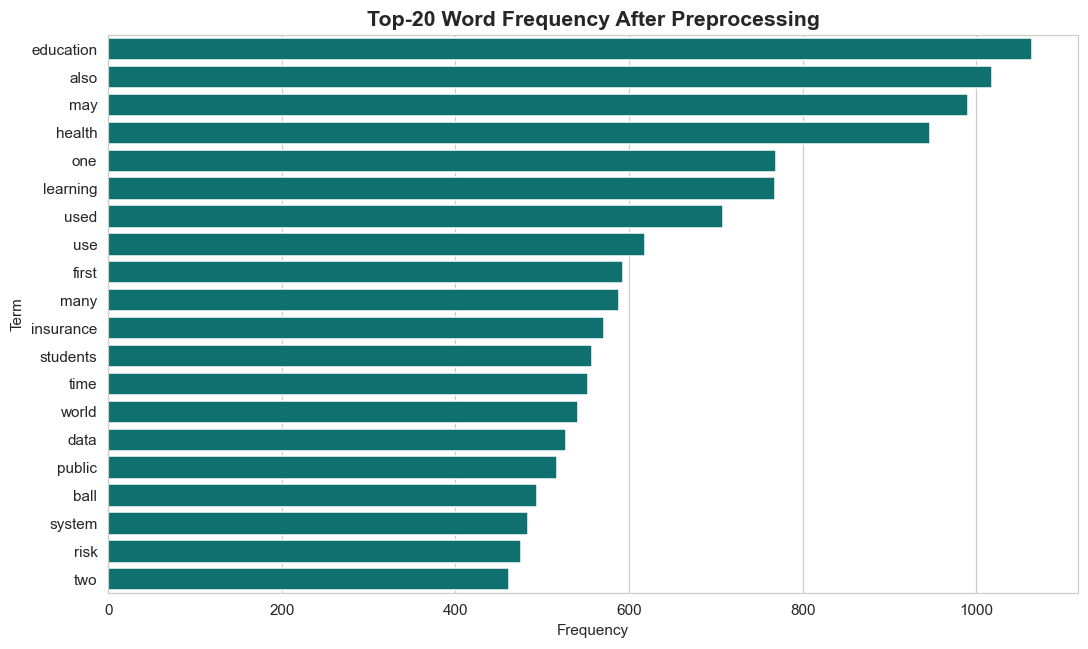

In [5]:
def plot_top_freq(counter, title, top_n=20, color="steelblue"):
    common = counter.most_common(top_n)
    words, counts = zip(*common) if common else ([], [])
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words), color=color)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Frequency")
    plt.ylabel("Term")
    plt.tight_layout()
    plt.show()

all_unigrams = Counter([tok for toks in df["unigrams"] for tok in toks])
all_bigrams  = Counter([tok for toks in df["bigrams"]  for tok in toks])
all_trigrams = Counter([tok for toks in df["trigrams"] for tok in toks])

plot_top_freq(all_unigrams, "Top-20 Word Frequency After Preprocessing", color="teal")

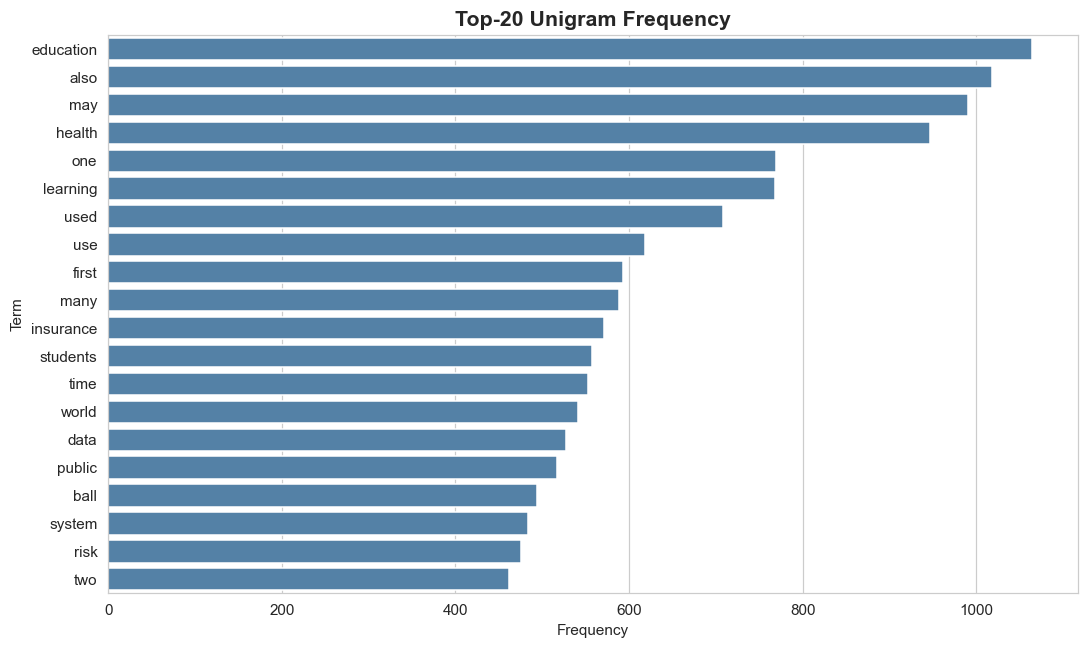

In [ ]:
# (b) Unigram frequency graph
plot_top_freq(all_unigrams, "Top-20 Unigram Frequency", color="steelblue")


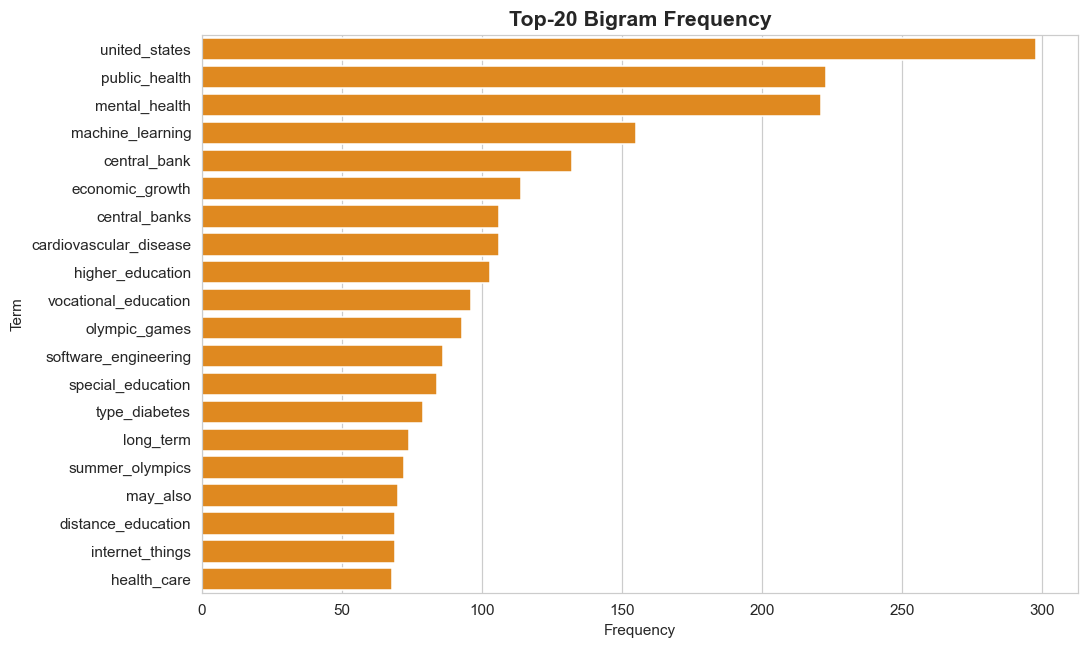

In [ ]:
# (c) Bigram frequency graph
plot_top_freq(all_bigrams, "Top-20 Bigram Frequency", color="darkorange")


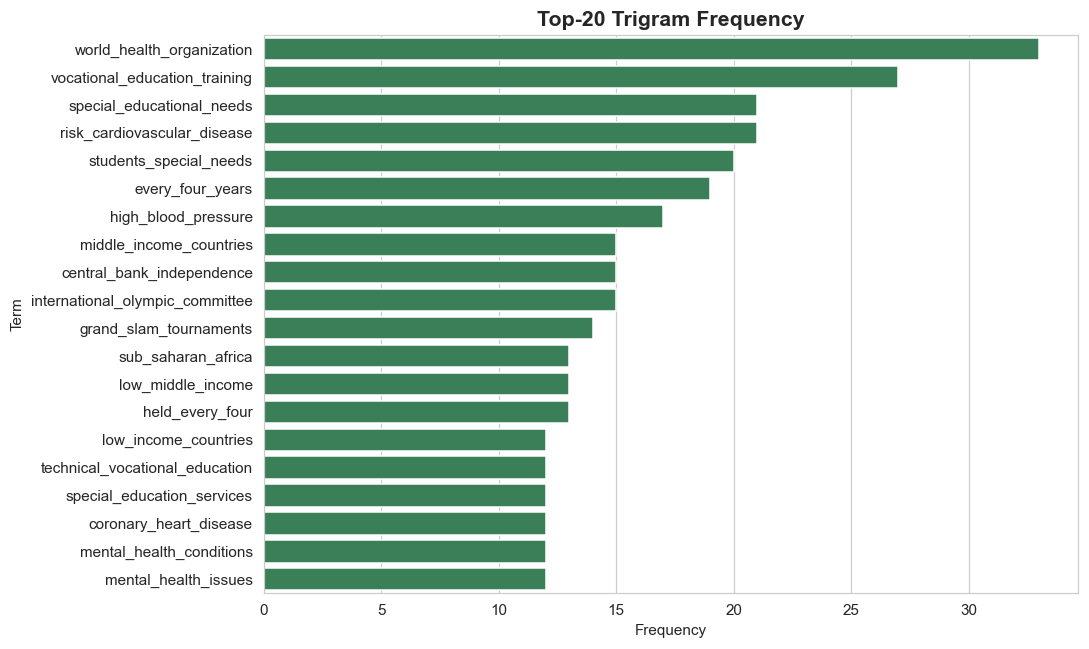

In [ ]:
# (d) Trigram frequency graph
plot_top_freq(all_trigrams, "Top-20 Trigram Frequency", color="seagreen")


In [ ]:
def train_w2v(corpus_series, sg, vector_size=100, window=4, min_count=2, epochs=60):
    sentences = [toks for toks in corpus_series if len(toks) > 1]
    model = Word2Vec(sentences=sentences, vector_size=vector_size, window=window,
                      min_count=min_count, sg=sg, workers=2, epochs=epochs, seed=RANDOM_STATE)
    return model

print("Training CBOW & Skip-gram models on unigram / bigram / trigram corpora ...")
models = {
    ("unigram", "CBOW"):     train_w2v(df["unigrams"], sg=0),
    ("unigram", "SkipGram"): train_w2v(df["unigrams"], sg=1),
    ("bigram",  "CBOW"):     train_w2v(df["bigrams"],  sg=0, min_count=2),
    ("bigram",  "SkipGram"): train_w2v(df["bigrams"],  sg=1, min_count=2),
    ("trigram", "CBOW"):     train_w2v(df["trigrams"], sg=0, min_count=2),
    ("trigram", "SkipGram"): train_w2v(df["trigrams"], sg=1, min_count=2),
}
for k, m in models.items():
    print(k, "-> vocab size:", len(m.wv))


Training CBOW & Skip-gram models on unigram / bigram / trigram corpora ...
('unigram', 'CBOW') -> vocab size: 12216
('unigram', 'SkipGram') -> vocab size: 12216
('bigram', 'CBOW') -> vocab size: 20681
('bigram', 'SkipGram') -> vocab size: 20681
('trigram', 'CBOW') -> vocab size: 5288
('trigram', 'SkipGram') -> vocab size: 5288


In [ ]:
def predict_next_word(model, query, topn=5):
    """Return the top-n most likely related/next words for a word or phrase."""
    query_tokens = query.lower().split()
    key = query_tokens[-1] if len(query_tokens) == 1 else "_".join(query_tokens)
    if key not in model.wv:
        return []
    return model.wv.most_similar(key, topn=topn)


# Pick a few example query words straight from the corpus vocabulary
example_words = [w for w, c in all_unigrams.most_common(30)][:5]
print("Example query words taken from the corpus:", example_words)

for w in example_words:
    print(f"\n--- Query word: '{w}' ---")
    cbow_pred = predict_next_word(models[("unigram", "CBOW")], w)
    sg_pred   = predict_next_word(models[("unigram", "SkipGram")], w)
    print("CBOW     :", cbow_pred)
    print("SkipGram :", sg_pred)


Example query words taken from the corpus: ['education', 'also', 'may', 'health', 'one']

--- Query word: 'education' ---
CBOW     : [('educational', 0.5388146638870239), ('tertiary', 0.4310488700866699), ('vocational', 0.4231206774711609), ('inclusive', 0.4188491404056549), ('classrooms', 0.41118571162223816)]
SkipGram : [('vocational', 0.7436927556991577), ('tertiary', 0.7199743986129761), ('mvtt', 0.6243951916694641), ('tafe', 0.6234667897224426), ('schools', 0.6152152419090271)]

--- Query word: 'also' ---
CBOW     : [('frequently', 0.33513832092285156), ('conversely', 0.3312748074531555), ('since', 0.3145321011543274), ('commonly', 0.31281712651252747), ('formerly', 0.3026615381240845)]
SkipGram : [('vle', 0.5204482078552246), ('gyms', 0.4986574947834015), ('commonly', 0.4932229220867157), ('utah', 0.49097734689712524), ('recommending', 0.4765576720237732)]

--- Query word: 'may' ---
CBOW     : [('could', 0.4519660174846649), ('might', 0.4078610837459564), ('cannot', 0.40094846487

     ngram     model  avg_top5_similarity
0  unigram      CBOW             0.395831
1  unigram  SkipGram             0.574165
2   bigram      CBOW             0.000000
3   bigram  SkipGram             0.000000
4  trigram      CBOW             0.000000
5  trigram  SkipGram             0.000000


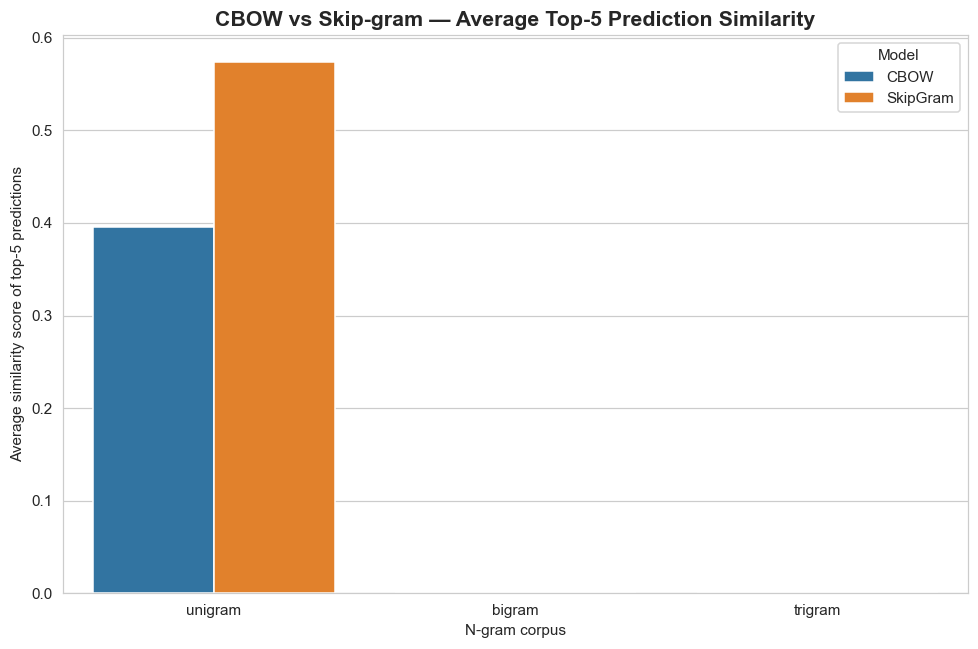

In [ ]:
def avg_topk_similarity(model, words, topn=5):
    scores = []
    for w in words:
        preds = predict_next_word(model, w, topn=topn)
        if preds:
            scores.append(np.mean([s for _, s in preds]))
    return np.mean(scores) if scores else 0.0

comparison_rows = []
for ngram in ["unigram", "bigram", "trigram"]:
    query_pool = [w for w in example_words]  # same query words for fair comparison
    cbow_score = avg_topk_similarity(models[(ngram, "CBOW")], query_pool)
    sg_score   = avg_topk_similarity(models[(ngram, "SkipGram")], query_pool)
    comparison_rows.append({"ngram": ngram, "model": "CBOW", "avg_top5_similarity": cbow_score})
    comparison_rows.append({"ngram": ngram, "model": "SkipGram", "avg_top5_similarity": sg_score})

cmp_df = pd.DataFrame(comparison_rows)
print(cmp_df)

plt.figure(figsize=(9, 6))
sns.barplot(data=cmp_df, x="ngram", y="avg_top5_similarity", hue="model")
plt.title("CBOW vs Skip-gram — Average Top-5 Prediction Similarity", fontsize=14, fontweight="bold")
plt.xlabel("N-gram corpus")
plt.ylabel("Average similarity score of top-5 predictions")
plt.legend(title="Model")
plt.tight_layout()
plt.show()


In [ ]:
X_text = df["cleaned_text"].values
y = df["category"].values

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y_enc, test_size=0.3, random_state=RANDOM_STATE, stratify=y_enc
)

ngram_settings = {
    "unigram": (1, 1),
    "bigram":  (1, 2),
    "trigram": (1, 3),
}

results = []
fitted_models = {}   # (ngram, clf_name) -> (vectorizer, model, y_pred)

for ngram_name, ngram_range in ngram_settings.items():
    vectorizer = TfidfVectorizer(ngram_range=ngram_range, min_df=1, max_features=5000)
    Xtr = vectorizer.fit_transform(X_train_text)
    Xte = vectorizer.transform(X_test_text)

    # ---- Naive Bayes ----
    nb = MultinomialNB()
    nb.fit(Xtr, y_train)
    pred_nb = nb.predict(Xte)
    p, r, f1, _ = precision_recall_fscore_support(y_test, pred_nb, average="weighted", zero_division=0)
    acc = accuracy_score(y_test, pred_nb)
    results.append({"ngram": ngram_name, "model": "NaiveBayes", "accuracy": acc,
                     "precision": p, "recall": r, "f1": f1})
    fitted_models[(ngram_name, "NaiveBayes")] = (vectorizer, nb, pred_nb)

    # ---- Logistic Regression ----
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    lr.fit(Xtr, y_train)
    pred_lr = lr.predict(Xte)
    p, r, f1, _ = precision_recall_fscore_support(y_test, pred_lr, average="weighted", zero_division=0)
    acc = accuracy_score(y_test, pred_lr)
    results.append({"ngram": ngram_name, "model": "LogisticRegression", "accuracy": acc,
                     "precision": p, "recall": r, "f1": f1})
    fitted_models[(ngram_name, "LogisticRegression")] = (vectorizer, lr, pred_lr)

results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
results_df


,ngram,model,accuracy,precision,recall,f1
0,unigram,NaiveBayes,1.0,1.0,1.0,1.0
1,unigram,LogisticRegression,1.0,1.0,1.0,1.0
2,bigram,NaiveBayes,1.0,1.0,1.0,1.0
3,bigram,LogisticRegression,1.0,1.0,1.0,1.0
4,trigram,NaiveBayes,1.0,1.0,1.0,1.0
5,trigram,LogisticRegression,1.0,1.0,1.0,1.0


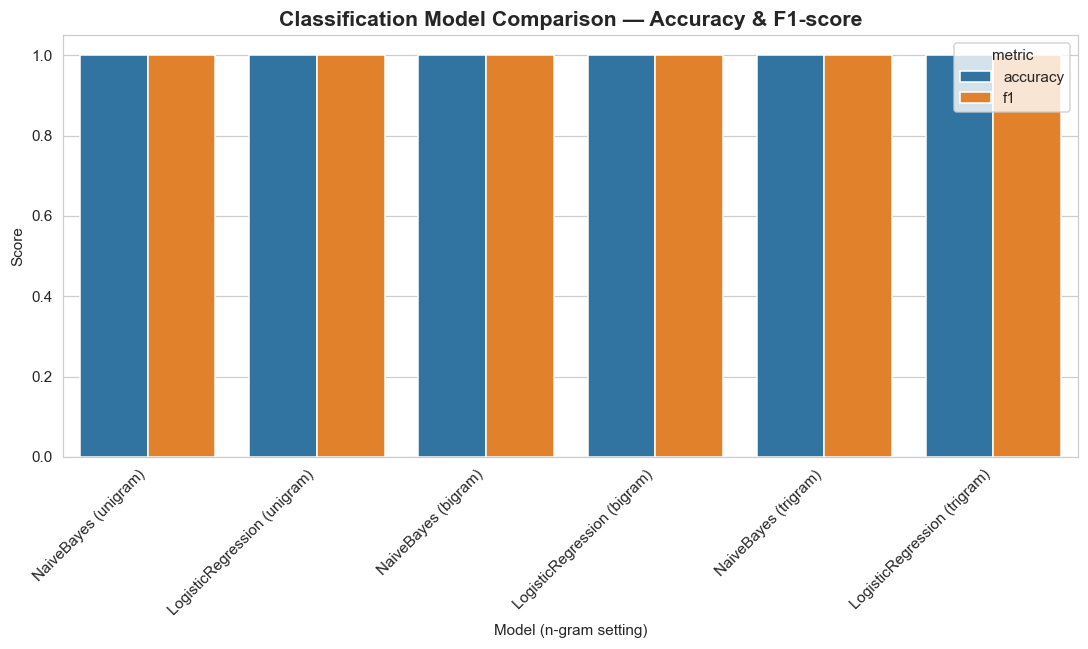

Best model: NaiveBayes on unigram features -> accuracy=1.000, F1=1.000


In [ ]:
plt.figure(figsize=(10, 6))
plot_df = results_df.melt(id_vars=["ngram", "model"], value_vars=["accuracy", "f1"],
                           var_name="metric", value_name="score")
plot_df["setting"] = plot_df["model"] + " (" + plot_df["ngram"] + ")"
sns.barplot(data=plot_df, x="setting", y="score", hue="metric")
plt.xticks(rotation=45, ha="right")
plt.title("Classification Model Comparison — Accuracy & F1-score", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.xlabel("Model (n-gram setting)")
plt.tight_layout()
plt.show()

best_row = results_df.iloc[0]
print(f"Best model: {best_row['model']} on {best_row['ngram']} features "
      f"-> accuracy={best_row['accuracy']:.3f}, F1={best_row['f1']:.3f}")


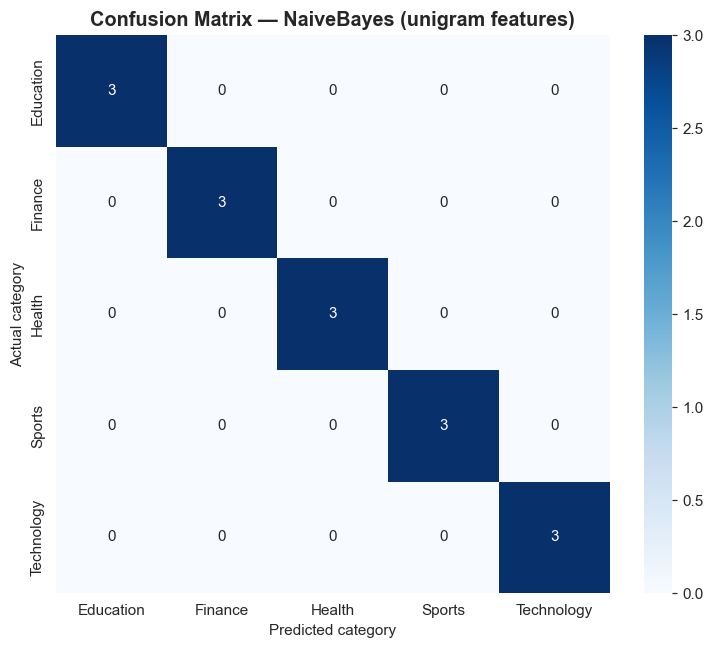

              precision    recall  f1-score   support

   Education       1.00      1.00      1.00         3
     Finance       1.00      1.00      1.00         3
      Health       1.00      1.00      1.00         3
      Sports       1.00      1.00      1.00         3
  Technology       1.00      1.00      1.00         3

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



In [ ]:
best_ngram, best_model_name = best_row["ngram"], best_row["model"]
_, _, best_pred = fitted_models[(best_ngram, best_model_name)]

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix — {best_model_name} ({best_ngram} features)", fontsize=13, fontweight="bold")
plt.xlabel("Predicted category")
plt.ylabel("Actual category")
plt.tight_layout()
plt.show()

print(classification_report(y_test, best_pred, target_names=le.classes_, zero_division=0))


## K-Means Clustering (Unsupervised) vs Original Labels
K-Means is applied on TF-IDF document vectors (unigram features, whole
corpus) with `k = number of true categories`, then compared against the
original folder labels using **Adjusted Rand Index (ARI)** and **Normalized
Mutual Information (NMI)**.

In [ ]:
tfidf_full = TfidfVectorizer(ngram_range=(1, 1), max_features=5000)
X_full = tfidf_full.fit_transform(df["cleaned_text"].values)

k = df["category"].nunique()
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_full)

true_labels = le.transform(df["category"].values)
ari = adjusted_rand_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)
print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print(f"Normalized Mutual Information (NMI): {nmi:.3f}")

# Contingency table: cluster vs original category
contingency = pd.crosstab(df["category"], cluster_labels, rownames=["Category"], colnames=["Cluster"])
contingency


Adjusted Rand Index (ARI): 0.572
Normalized Mutual Information (NMI): 0.723


Cluster,0,1,2,3,4
Category,,,,,
Education,0,0,0,10,0
Finance,1,0,8,1,0
Health,0,0,0,1,9
Sports,0,9,0,0,1
Technology,1,0,0,9,0


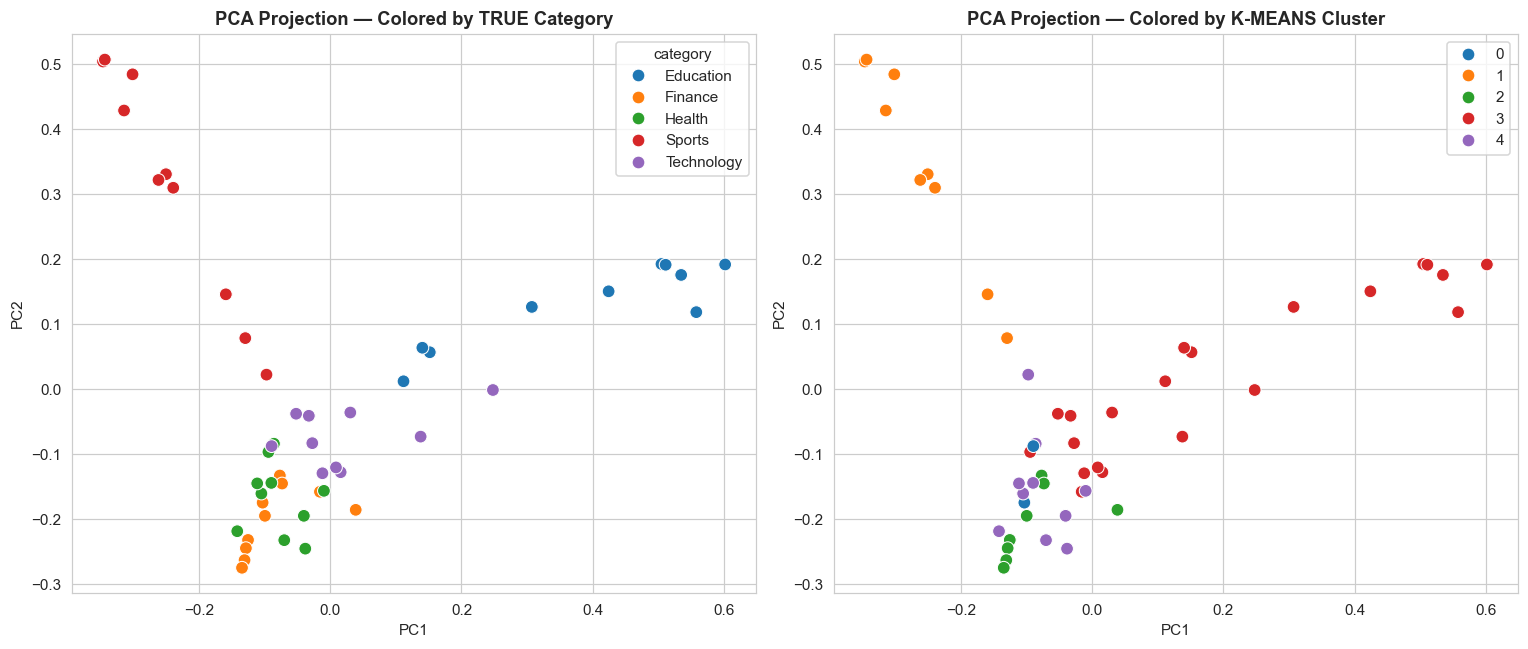

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_full.toarray())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=df["category"], palette="tab10", ax=axes[0], s=70)
axes[0].set_title("PCA Projection — Colored by TRUE Category", fontweight="bold")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=cluster_labels, palette="tab10", ax=axes[1], s=70)
axes[1].set_title("PCA Projection — Colored by K-MEANS Cluster", fontweight="bold")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()


In [ ]:

import os

RESULTS_OUTPUT_DIR = "output_results"
os.makedirs(RESULTS_OUTPUT_DIR, exist_ok=True)

# 1) Classification model comparison (Naive Bayes vs Logistic Regression,
#    across unigram/bigram/trigram) with accuracy, precision, recall, F1
results_df.to_csv(os.path.join(RESULTS_OUTPUT_DIR, "classification_model_comparison.csv"), index=False)
print("Saved -> output_results/classification_model_comparison.csv")

# 2) CBOW vs Skip-gram comparison (Part A)
cmp_df.to_csv(os.path.join(RESULTS_OUTPUT_DIR, "cbow_vs_skipgram_comparison.csv"), index=False)
print("Saved -> output_results/cbow_vs_skipgram_comparison.csv")

# 3) K-Means cluster vs true-category contingency table
contingency.to_csv(os.path.join(RESULTS_OUTPUT_DIR, "kmeans_vs_true_labels_contingency.csv"))
print("Saved -> output_results/kmeans_vs_true_labels_contingency.csv")

# 4) K-Means quality metrics (ARI / NMI) as a small summary CSV
import pandas as pd
kmeans_summary = pd.DataFrame([{"metric": "Adjusted Rand Index (ARI)", "value": ari},
                                {"metric": "Normalized Mutual Information (NMI)", "value": nmi}])
kmeans_summary.to_csv(os.path.join(RESULTS_OUTPUT_DIR, "kmeans_quality_metrics.csv"), index=False)
print("Saved -> output_results/kmeans_quality_metrics.csv")

print(f"\nAll comparison CSVs saved inside: {RESULTS_OUTPUT_DIR}/")

Saved -> output_results/classification_model_comparison.csv
Saved -> output_results/cbow_vs_skipgram_comparison.csv
Saved -> output_results/kmeans_vs_true_labels_contingency.csv
Saved -> output_results/kmeans_quality_metrics.csv

All comparison CSVs saved inside: output_results/
